# EEGTCNet v4: Higher Temporal Resolution + Fine-Tuning

**Architecture changes from v3 (78.1% LOSO):**
1. **Standard Transformer** (not Swin) — ablation showed Swin adds only +0.9%
2. **75 tokens** via AvgPool(kernel=25, stride=8) — vs v3's 37 tokens (+4.3% in ablation)
3. **Keep**: 64 channels, CCST augmentation, channel-wise z-score, bandpass 7-30 Hz

**New experiment: LOSO + Fine-Tuning**
- Pre-train on N-1 subjects (LOSO), then fine-tune on a small calibration set from the held-out subject
- Test at 5%, 10%, 20% calibration fractions → calibration curve
- Answers: "How much calibration data from a new user is needed?"

**Configurable dataset size**: `N_SUBJECTS_USED = 20` for quick tests, set to 109 for full run

**v3 benchmarks**: LOSO 78.1%, Within-subject 69.0% | **CCST benchmark**: LOSO 71.70%

**Reference**: Qamar & Abibullaev, "Multi-scale EEG feature decoding with Swin Transformers", Scientific Reports 2026

## 1. Imports & Configuration

In [ ]:
# import os
# import numpy as np
# SAVE_DIR = '/content/drive/My Drive/saved_models_v4'
# os.makedirs(SAVE_DIR, exist_ok=True)
# np.save(os.path.join(SAVE_DIR, 'test_save.txt'), np.array([1,2,3,4,5]))


In [ ]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

import mne
mne.set_log_level('WARNING')

import torch
import torch.nn as nn
import torch.nn.functional as F

from scipy.signal import butter, filtfilt
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut, train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, cohen_kappa_score)

def set_random_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_random_seeds(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"PyTorch: {torch.__version__}, Device: {device}")

# Dataset constants 
N_SUBJECTS_TOTAL = 109 # Full PhysioNet dataset
N_SUBJECTS_USED  = 109 # CHANGE TO 109 FOR FULL RUN
N_CHANNELS = 64 # ALL channels
SFREQ = 160 # Hz - Signal Frequency
N_CLASSES = 2 # Left Fist, Right Fist
EPOCH_SAMPLES = 641 # MNE gives 641 for tmax=4.0 @ 160Hz

MI_ME_RUNS = [3, 4, 7, 8, 11, 12]  # All 6 L/R fist runs

BANDPASS_LOW  = 7.0 # CCST uses 7-30 Hz
BANDPASS_HIGH = 30.0

# Training (matching CCST)
LR = 3e-4
BATCH_SIZE = 72
MAX_EPOCHS = 150
PATIENCE = 10
WEIGHT_DECAY = 1e-4 # L2 regularization for LOSO training

# Fine-tuning
FT_LR         = 1e-4
FT_EPOCHS     = 30
FT_BATCH_SIZE = 16
FT_PATIENCE   = 5
CALIBRATION_FRACTIONS = [0.05, 0.10, 0.20]

# ── Colab paths ──
DATA_DIR = '/content/drive/My Drive/physionet_data'
SAVE_DIR = '/content/drive/My Drive/saved_models_v4'

print(f"Config: {N_SUBJECTS_USED}/{N_SUBJECTS_TOTAL} subjects, {N_CHANNELS} ch, {SFREQ} Hz, "
      f"{N_CLASSES} classes, window={EPOCH_SAMPLES} samples")
print(f"Runs: {MI_ME_RUNS} (6 runs = 3 execution + 3 imagery)")
print(f"Bandpass: {BANDPASS_LOW}-{BANDPASS_HIGH} Hz")
print(f"Fine-tuning fractions: {CALIBRATION_FRACTIONS}")

PyTorch: 2.10.0+cu128, Device: cuda
Config: 20/109 subjects, 64 ch, 160 Hz, 2 classes, window=641 samples
Runs: [3, 4, 7, 8, 11, 12] (6 runs = 3 execution + 3 imagery)
Bandpass: 7.0-30.0 Hz
Fine-tuning fractions: [0.05, 0.1, 0.2]


## 2. Mount Google Drive

In [ ]:
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'Data dir: {DATA_DIR}')
print(f'Save dir: {SAVE_DIR}')
print(f'Drive contents: {os.listdir("/content/drive/My Drive")[:10]}')

Data dir: /content/drive/My Drive/physionet_data
Save dir: /content/drive/My Drive/saved_models_v4


## 3. Data Loading Functions

In [ ]:
def load_physionet_subject(subject_id, runs=MI_ME_RUNS, data_dir=DATA_DIR):
    """Load PhysioNet EDF files for a subject and extract motor imagery/execution epochs
       Uses all 64 channels and ALL 6 L/R fist runs
    """
    subject_name = f'S{subject_id:03d}'
    all_epochs, all_labels = [], []

    for run in runs:
        edf_path = os.path.join(data_dir, f'{subject_name}R{run:02d}.edf')
        if not os.path.exists(edf_path):
            edf_path = os.path.join(data_dir, subject_name, f'{subject_name}R{run:02d}.edf')
            if not os.path.exists(edf_path):
                continue

        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

        if raw.info['sfreq'] != SFREQ:
            raw = raw.copy().resample(SFREQ, verbose=False)

        rename_map = {ch: ch.rstrip('.') for ch in raw.info['ch_names']}
        raw.rename_channels(rename_map)

        events, event_id = mne.events_from_annotations(raw, verbose=False)
        mi_event_id = {k: v for k, v in event_id.items() if k in ('T1', 'T2')}

        if len(mi_event_id) < 2:
            continue

        epochs = mne.Epochs(raw, events, event_id=mi_event_id,
                            tmin=0.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
        data = epochs.get_data()

        if data.shape[2] > EPOCH_SAMPLES:
            data = data[:, :, :EPOCH_SAMPLES]

        t1_val, t2_val = mi_event_id['T1'], mi_event_id['T2']
        for i, ev in enumerate(epochs.events[:, 2]):
            if ev == t1_val:
                all_labels.append(0)
                all_epochs.append(data[i])
            elif ev == t2_val:
                all_labels.append(1)
                all_epochs.append(data[i])

    if not all_epochs:
        return None

    return np.array(all_epochs), np.array(all_labels)


def load_all_subjects(data_dir=DATA_DIR, n_subjects=N_SUBJECTS_USED):
    #Load PhysioNet data for N_SUBJECTS_USED subjects
    subjects_data = {}
    for sid in range(1, n_subjects + 1):
        result = load_physionet_subject(sid, data_dir=data_dir)
        if result is not None:
            X, y = result
            subjects_data[sid] = (X, y)
            print(f'  Subject {sid:03d}: {len(X)} epochs '
                  f'(Left={np.sum(y==0)}, Right={np.sum(y==1)})')
    return subjects_data


print('Data loading functions ready.')

Data loading functions ready.


## 4. Preprocessing Pipeline (CCST-aligned)

In [ ]:
def bandpass_filter(X_trials, sfreq=SFREQ, low_freq=BANDPASS_LOW, high_freq=BANDPASS_HIGH, order=5):
    #FIR bandpass filter (7-30 Hz)
    nyquist = sfreq / 2
    b, a = butter(order, [low_freq / nyquist, high_freq / nyquist], btype='band')
    X_filtered = np.zeros_like(X_trials)
    for i, trial in enumerate(X_trials):
        X_filtered[i] = filtfilt(b, a, trial, axis=1)
    return X_filtered


def channel_wise_zscore(X_trials):
    # Channel-wise z-score normalization (CCST approach)
    N, C, T = X_trials.shape
    X_flat = X_trials.reshape(N, C * T)
    mean = X_flat.mean(axis=0, keepdims=True)
    std = X_flat.std(axis=0, keepdims=True) + 1e-8
    X_normalized = (X_flat - mean) / std
    return X_normalized.reshape(N, C, T)


def channel_wise_zscore_from_train(X_train, X_test):
    # Channel-wise z-score using training set statistics only (prevent data leakage)
    N_train, C, T = X_train.shape
    N_test = X_test.shape[0]

    X_train_flat = X_train.reshape(N_train, C * T)
    mean = X_train_flat.mean(axis=0, keepdims=True)
    std = X_train_flat.std(axis=0, keepdims=True) + 1e-8

    X_train_norm = (X_train.reshape(N_train, C * T) - mean) / std
    X_test_norm = (X_test.reshape(N_test, C * T) - mean) / std

    return X_train_norm.reshape(N_train, C, T), X_test_norm.reshape(N_test, C, T)


def preprocess_per_subject(X_trials, y_trials, sfreq=SFREQ):
    # Per-subject preprocessing: bandpass + channel-wise z-score 
    X = bandpass_filter(X_trials, sfreq=sfreq)
    X = channel_wise_zscore(X)
    return X, y_trials


print('Preprocessing functions ready.')

Preprocessing functions ready.


## 5. CCST-style Data Augmentation

In [ ]:
def ccst_augment(X, y, shift_max=10, noise_std=0.01, dropout_rate=0.05, augment_factor=1):
    # CCST-style augmentation: temporal shift + Gaussian noise + electrode dropout
    if augment_factor == 0:
        return X, y

    X_aug_list, y_aug_list = [X], [y]

    for _ in range(augment_factor):
        X_new = X.copy()

        # Temporal shift
        for i in range(len(X_new)):
            shift = np.random.randint(-shift_max, shift_max + 1)
            X_new[i] = np.roll(X_new[i], shift, axis=1)

        # Gaussian noise
        X_new += np.random.randn(*X_new.shape) * noise_std

        # Electrode dropout (5%)
        for i in range(len(X_new)):
            drop_mask = np.random.rand(X_new.shape[1]) < dropout_rate
            X_new[i, drop_mask, :] = 0.0

        X_aug_list.append(X_new)
        y_aug_list.append(y)

    return np.concatenate(X_aug_list), np.concatenate(y_aug_list)


print('Augmentation function ready.')

Augmentation function ready.


## 6. Load Dataset

In [ ]:
print(f'Loading PhysioNet data ({N_SUBJECTS_USED} subjects, {N_CHANNELS} channels)...')

subjects_data = load_all_subjects(data_dir=DATA_DIR, n_subjects=N_SUBJECTS_USED)

print(f'Total subjects loaded: {len(subjects_data)}')

all_counts = [len(y) for _, y in subjects_data.values()]
all_y = np.concatenate([y for _, y in subjects_data.values()])
print(f'Total epochs: {len(all_y)}')
print(f'Trials per subject: min={min(all_counts)}, max={max(all_counts)}, mean={np.mean(all_counts):.1f}')
print(f'Left Fist (T1): {np.sum(all_y==0)}, Right Fist (T2): {np.sum(all_y==1)}')

Loading PhysioNet data (20 subjects, 64 channels)...
  Subject 001: 90 epochs (Left=46, Right=44)
  Subject 002: 90 epochs (Left=46, Right=44)
  Subject 003: 90 epochs (Left=45, Right=45)
  Subject 004: 90 epochs (Left=45, Right=45)
  Subject 005: 90 epochs (Left=44, Right=46)
  Subject 006: 90 epochs (Left=46, Right=44)
  Subject 007: 90 epochs (Left=46, Right=44)
  Subject 008: 90 epochs (Left=44, Right=46)
  Subject 009: 90 epochs (Left=47, Right=43)
  Subject 010: 90 epochs (Left=48, Right=42)
  Subject 011: 90 epochs (Left=45, Right=45)
  Subject 012: 90 epochs (Left=45, Right=45)
  Subject 013: 90 epochs (Left=47, Right=43)
  Subject 014: 90 epochs (Left=44, Right=46)
  Subject 015: 90 epochs (Left=45, Right=45)
  Subject 016: 90 epochs (Left=45, Right=45)
  Subject 017: 90 epochs (Left=46, Right=44)
  Subject 018: 90 epochs (Left=44, Right=46)
  Subject 019: 90 epochs (Left=47, Right=43)
  Subject 020: 90 epochs (Left=44, Right=46)
Total subjects loaded: 20
Total epochs: 1800
Tr

## 7. Preprocessing Execution

In [ ]:
print('Applying per-subject preprocessing: bandpass(7-30 Hz) + channel-wise z-score')

preprocessed_data = {}
for sid, (X, y) in subjects_data.items():
    X_pp, y_pp = preprocess_per_subject(X, y)
    preprocessed_data[sid] = (X_pp, y_pp)

print(f'Preprocessed {len(preprocessed_data)} subjects.')

X0, y0 = list(preprocessed_data.values())[0]
print(f'  Sample shape: {X0.shape}, range: [{X0.min():.3f}, {X0.max():.3f}]')

Applying per-subject preprocessing: bandpass(7-30 Hz) + channel-wise z-score
Preprocessed 20 subjects.
  Sample shape: (90, 64, 641), range: [-6.966, 6.242]


## 8. Model Definition — EEGTCNet v4

Changes from v3:
- **Standard Transformer** (not Swin) — ablation showed +0.9% only
- **75 tokens** via AvgPool(kernel=25, stride=8) — ablation showed +4.3% vs 37 tokens
- ~210k params

In [ ]:
# ── Patch Embedding ──

class PatchEmbedding(nn.Module):
    """CCST-style patch embedding with configurable pooling.
    v4 default: pool_kernel=25, pool_stride=8 -> 75 tokens
    v3 default: pool_kernel=75, pool_stride=15 -> 37 tokens
    """
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 pool_kernel=25, pool_stride=8):
        super().__init__()
        self.conv_temp = nn.Conv2d(1, 40, kernel_size=(1, 25), stride=(1, 1), padding=(0, 0))
        self.conv_spat = nn.Conv2d(40, 40, kernel_size=(in_channels, 1), stride=(1, 1), padding=(0, 0))
        self.bn = nn.BatchNorm2d(40)
        self.act = nn.ELU()
        self.pool = nn.AvgPool2d(kernel_size=(1, pool_kernel), stride=(1, pool_stride))
        self.drop = nn.Dropout(p=0.5)
        self.proj = nn.Conv2d(40, emb_size, kernel_size=(1, 1), stride=(1, 1))
        self.input_time_len = input_time_len
        self.pool_kernel = pool_kernel
        self.pool_stride = pool_stride

    def compute_seq_len(self):
        W1 = self.input_time_len - 25 + 1
        if W1 < self.pool_kernel:
            Wp = 1
        else:
            Wp = (W1 - self.pool_kernel) // self.pool_stride + 1
            Wp = max(1, Wp)
        return Wp

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.conv_temp(x)      # (B, 40, C, T-24)
        x = self.conv_spat(x)      # (B, 40, 1, T-24)
        x = self.bn(x)
        x = self.act(x)
        x = self.pool(x)           # (B, 40, 1, Wp)
        x = self.drop(x)
        x = self.proj(x)           # (B, emb_size, 1, Wp)
        x = x.squeeze(2)          # (B, emb_size, Wp)
        x = x.permute(0, 2, 1)    # (B, Wp, emb_size)
        return x


# Standard Transformer

class StandardTransformerBlock(nn.Module):
    # Standard Pre-LN Transformer block (global attention, no windows)
    def __init__(self, dim, num_heads, mlp_hidden=128, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.ln2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        shortcut = x
        x = self.ln1(x)
        x_attn, _ = self.attn(x, x, x)
        x = shortcut + x_attn
        shortcut = x
        x = self.ln2(x)
        x = shortcut + self.mlp(x)
        return x


class StandardTransformer(nn.Module):
    # Stack of standard Transformer blocks for EEG
    def __init__(self, dim=64, num_layers=3, num_heads=4, mlp_hidden=128, dropout=0.1):
        super().__init__()
        blocks = [StandardTransformerBlock(dim=dim, num_heads=num_heads,
                                           mlp_hidden=mlp_hidden, dropout=dropout)
                  for _ in range(num_layers)]
        self.blocks = nn.ModuleList(blocks)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        x = x.mean(dim=1)  # GAP
        return x


# EEGTCNet v4

class EEGTCNetV4(nn.Module):
    """EEGTCNet v4: Standard Transformer with higher temporal resolution.

    Key changes from v3:
    - Standard Transformer (not Swin) — ablation showed Swin adds only +0.9%
    - 75 tokens via AvgPool(kernel=25, stride=8) — ablation showed +4.3% vs 37 tokens
    - Same patch embedding (temporal conv + spatial conv + BN + ELU + AvgPool)
    """
    def __init__(self, in_channels=64, input_time_len=641, emb_size=40,
                 tf_dim=64, num_tf_layers=3, num_heads=4,
                 mlp_hidden=128, num_classes=2,
                 pool_kernel=25, pool_stride=8):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            in_channels=in_channels, input_time_len=input_time_len,
            emb_size=emb_size, pool_kernel=pool_kernel, pool_stride=pool_stride
        )
        self.seq_len = self.patch_embedding.compute_seq_len()
        self.embedding_projection = nn.Linear(emb_size, tf_dim)
        self.pos_encoding = nn.Parameter(torch.zeros(1, self.seq_len, tf_dim))
        nn.init.trunc_normal_(self.pos_encoding, std=0.02)
        self.transformer = StandardTransformer(
            dim=tf_dim, num_layers=num_tf_layers, num_heads=num_heads,
            mlp_hidden=mlp_hidden, dropout=0.1
        )
        self.classification_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(tf_dim, num_classes)
        )

    def forward(self, x):
        # x: (B, 1, C, T)
        x = self.patch_embedding(x)          # (B, seq_len, emb_size)
        x = self.embedding_projection(x)     # (B, seq_len, tf_dim)
        x = x + self.pos_encoding[:, :x.size(1), :]
        features = self.transformer(x)       # (B, tf_dim)
        logits = self.classification_head(features)
        return logits


def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


print('EEGTCNet v4 model defined!')

EEGTCNet v4 model defined!


## 9. Model Summary

In [ ]:
model = EEGTCNetV4(in_channels=N_CHANNELS, input_time_len=EPOCH_SAMPLES, num_classes=N_CLASSES)
total_params, trainable_params = count_parameters(model)
print('EEGTCNet v4 Architecture')
print(f'Parameters: total={total_params:,}  trainable={trainable_params:,}')
print(f'Sequence length (tokens): {model.seq_len}')

for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    print(f'  {name}: {params:,}')

dummy = torch.randn(2, 1, N_CHANNELS, EPOCH_SAMPLES)
out = model(dummy)
print(f'\nInput:  {dummy.shape}')
print(f'Output: {out.shape}')

print(f'\nComparison:')
print(f'  v3: 210,290 params, 37 tokens, Swin Transformer')
print(f'  v4: {total_params:,} params, {model.seq_len} tokens, Standard Transformer')

EEGTCNet v4 Architecture
Parameters: total=213,298  trainable=213,298
Sequence length (tokens): 75
  patch_embedding: 105,200
  embedding_projection: 2,624
  transformer: 100,544
  classification_head: 130

Input:  torch.Size([2, 1, 64, 641])
Output: torch.Size([2, 2])

Comparison:
  v3: 210,290 params, 37 tokens, Swin Transformer
  v4: 213,298 params, 75 tokens, Standard Transformer


## 10. Training Utilities

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0.0, mode='acc'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        if mode == 'acc':
            self.best = 0.0
        else:
            self.best = float('inf')
        self.best_state = None

    def __call__(self, metric, model):
        improved = False
        if self.mode == 'acc':
            if metric > self.best + self.min_delta:
                self.best = metric
                improved = True
        else:  # loss mode
            if metric < self.best - self.min_delta:
                self.best = metric
                improved = True

        if improved:
            self.best_state = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore(self, model):
        if self.best_state:
            model.load_state_dict(self.best_state)
        return model


def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        X_t = torch.FloatTensor(X_test).to(device)
        if X_t.dim() == 3:
            X_t = X_t.unsqueeze(1)
        outputs = model(X_t)
        probs = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)
    acc = accuracy_score(y_test, predicted.cpu().numpy())
    return acc, predicted.cpu().numpy(), probs.cpu().numpy()


def train_model(model, X_train, y_train, X_val, y_val,
                epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
                patience=PATIENCE, augment_factor=1, verbose=True):
    # Train with Adam + ReduceLROnPlateau (CCST training setup)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5
    )

    # CCST-style augmentation on training data
    X_aug, y_aug = ccst_augment(X_train, y_train, augment_factor=augment_factor)

    # Add channel dim if needed
    if X_aug.ndim == 3:
        X_aug = X_aug[:, np.newaxis, :, :]
        X_val_4d = X_val[:, np.newaxis, :, :] if X_val.ndim == 3 else X_val
    else:
        X_val_4d = X_val

    X_train_t = torch.FloatTensor(X_aug).to(device)
    y_train_t = torch.LongTensor(y_aug).to(device)
    X_val_t = torch.FloatTensor(X_val_4d).to(device)
    y_val_t = torch.LongTensor(y_val).to(device)

    early_stopper = EarlyStopping(patience=patience, mode='acc')
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(len(X_train_t))
        epoch_loss, correct, total = 0, 0, 0

        for i in range(0, len(X_train_t), batch_size):
            X_b = X_train_t[perm[i:i+batch_size]]
            y_b = y_train_t[perm[i:i+batch_size]]
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            _, pred = torch.max(out, 1)
            total += y_b.size(0)
            correct += (pred == y_b).sum().item()

        train_loss = epoch_loss / (len(X_train_t) // batch_size + 1)
        train_acc = correct / total

        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            _, val_pred = torch.max(val_out, 1)
            val_acc = (val_pred == y_val_t).sum().item() / len(y_val_t)

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if verbose and (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:3d} | Train: {train_loss:.4f}/{train_acc:.4f} | Val: {val_loss:.4f}/{val_acc:.4f}')

        if early_stopper(val_acc, model):
            if verbose:
                print(f'  Early stopping at epoch {epoch+1}')
            model = early_stopper.restore(model)
            break

    return history


def finetune_model(pretrained_state, model_class, model_kwargs,
                   X_calib, y_calib, X_test, y_test,
                   lr=FT_LR, epochs=FT_EPOCHS, batch_size=FT_BATCH_SIZE,
                   patience=FT_PATIENCE, verbose=True):
    model = model_class(**model_kwargs)
    model.load_state_dict(pretrained_state)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))

    # No augmentation for fine-tuning (too few samples)
    if X_calib.ndim == 3:
        X_calib = X_calib[:, np.newaxis, :, :]
        X_test_4d = X_test[:, np.newaxis, :, :] if X_test.ndim == 3 else X_test
    else:
        X_test_4d = X_test

    X_cal_t = torch.FloatTensor(X_calib).to(device)
    y_cal_t = torch.LongTensor(y_calib).to(device)
    X_test_t = torch.FloatTensor(X_test_4d).to(device)
    y_test_t = torch.LongTensor(y_test).to(device)

    early_stopper = EarlyStopping(patience=patience, mode='loss')

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_cal_t)
        loss = criterion(out, y_cal_t)
        loss.backward()
        optimizer.step()

        # Evaluate on calibration set for early stopping
        model.eval()
        with torch.no_grad():
            cal_loss = criterion(model(X_cal_t), y_cal_t).item()

        if verbose and (epoch + 1) % 10 == 0:
            _, pred = torch.max(model(X_test_t), 1)
            test_acc = (pred == y_test_t).sum().item() / len(y_test_t)
            print(f'    FT Epoch {epoch+1:3d} | Cal loss: {cal_loss:.4f} | Test acc: {test_acc:.4f}')

        if early_stopper(cal_loss, model):
            if verbose:
                print(f'    Fine-tune early stop at epoch {epoch+1}')
            model = early_stopper.restore(model)
            break

    # Final evaluation
    acc, _, _ = evaluate_model(model, X_test, y_test)
    return acc, model


print('Training utilities ready.')

Training utilities ready.


## 11. Experiment 1: LOSO Cross-Subject Evaluation

Leave-One-Subject-Out: train on N-1 subjects, test on 1.
10% of training data for validation (early stopping).
Models saved to Google Drive for fine-tuning later.

Target: exceed v3's 78.1% and CCST's 71.70%.

In [ ]:
print(f'Experiment 1: LOSO Cross-Subject Evaluation ({N_SUBJECTS_USED} subjects)')

all_sids = sorted(preprocessed_data.keys())
loso_results = []

model_kwargs = {
    'in_channels': N_CHANNELS,
    'input_time_len': EPOCH_SAMPLES,
    'num_classes': N_CLASSES
}

for fold_i, test_sid in enumerate(all_sids):
    print(f'\n--- Fold {fold_i+1}/{len(all_sids)}: Test subject {test_sid:03d} ---')

    train_sids = [s for s in all_sids if s != test_sid]
    X_train_arr = np.concatenate([preprocessed_data[s][0] for s in train_sids])
    y_train_arr = np.concatenate([preprocessed_data[s][1] for s in train_sids])
    X_test_arr, y_test_arr = preprocessed_data[test_sid]

    # Channel-wise z-score from training set only
    X_train_norm, X_test_norm = channel_wise_zscore_from_train(X_train_arr, X_test_arr)

    # Split training: 90% train, 10% validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_norm, y_train_arr, test_size=0.1,
        stratify=y_train_arr, random_state=42+fold_i
    )

    # Build fresh model
    model_loso = EEGTCNetV4(**model_kwargs)
    history = train_model(
        model_loso, X_tr, y_tr, X_val, y_val,
        epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
        patience=PATIENCE, augment_factor=1, verbose=True
    )

    acc, _, _ = evaluate_model(model_loso, X_test_norm, y_test_arr)
    loso_results.append({'subject': test_sid, 'accuracy': acc})
    print(f'  Test subject {test_sid:03d}: acc={acc:.4f} ({acc*100:.1f}%)')

    # Save model checkpoint to Drive
    torch.save(model_loso.state_dict(), os.path.join(SAVE_DIR, f'loso_subject_{test_sid:03d}.pt'))

loso_accs = np.array([r['accuracy'] for r in loso_results])

print(f'LOSO Mean Accuracy: {loso_accs.mean():.4f} +/- {loso_accs.std():.4f}')
print(f'Min: {loso_accs.min():.4f}, Max: {loso_accs.max():.4f}, Median: {np.median(loso_accs):.4f}')
print(f'v3 benchmark: 78.1%, CCST benchmark: 71.70%')
print(f'Above chance (>50%): {np.sum(loso_accs > 0.5)}/{len(loso_results)}')

Experiment 1: LOSO Cross-Subject Evaluation (20 subjects)

--- Fold 1/20: Test subject 001 ---
  Epoch  10 | Train: 0.3642/0.8411 | Val: 0.5330/0.7602
  Epoch  20 | Train: 0.1710/0.9295 | Val: 0.7177/0.7836
  Early stopping at epoch 21
  Test subject 001: acc=0.7889 (78.9%)

--- Fold 2/20: Test subject 002 ---
  Epoch  10 | Train: 0.4381/0.8047 | Val: 0.6568/0.6901
  Epoch  20 | Train: 0.1974/0.9256 | Val: 0.5762/0.7836
  Early stopping at epoch 29
  Test subject 002: acc=0.8667 (86.7%)

--- Fold 3/20: Test subject 003 ---
  Epoch  10 | Train: 0.3421/0.8496 | Val: 0.5322/0.7368
  Epoch  20 | Train: 0.1588/0.9422 | Val: 0.6690/0.7485
  Early stopping at epoch 21
  Test subject 003: acc=0.5889 (58.9%)

--- Fold 4/20: Test subject 004 ---
  Epoch  10 | Train: 0.3981/0.8184 | Val: 0.4880/0.7427
  Epoch  20 | Train: 0.2060/0.9149 | Val: 0.6198/0.7602
  Early stopping at epoch 27
  Test subject 004: acc=0.8111 (81.1%)

--- Fold 5/20: Test subject 005 ---
  Epoch  10 | Train: 0.3705/0.8327 | 

## 12. Experiment 2: LOSO + Fine-Tuning

For each held-out subject, take the pre-trained LOSO model and fine-tune
with a small calibration set from that subject.

Tests: "How much calibration data from a new user is needed?"
Calibration fractions: 5% (~4 trials), 10% (~9 trials), 20% (~18 trials)

In [ ]:
print(f'Experiment 2: LOSO + Fine-Tuning ({N_SUBJECTS_USED} subjects)')
print(f'Calibration fractions: {CALIBRATION_FRACTIONS}')

ft_results = {}  # {fraction: [acc_per_subject]}

for frac in CALIBRATION_FRACTIONS:
    frac_key = f'{int(frac*100)}%'
    ft_results[frac_key] = []
    print(f'\n=== Calibration fraction: {frac_key} ===')

    for test_sid in all_sids:
        # Load pre-trained LOSO model
        ckpt_path = os.path.join(SAVE_DIR, f'loso_subject_{test_sid:03d}.pt')
        if not os.path.exists(ckpt_path):
            print(f'  Subject {test_sid:03d}: checkpoint not found, skipping')
            continue

        pretrained_state = torch.load(ckpt_path, map_location=device)

        # Get held-out subject's data
        X_test_raw, y_test_raw = preprocessed_data[test_sid]

        # Split: fraction for calibration, rest for test
        try:
            X_cal, X_te, y_cal, y_te = train_test_split(
                X_test_raw, y_test_raw,
                train_size=frac, stratify=y_test_raw,
                random_state=42
            )
        except ValueError:
            # Too few samples for stratified split at this fraction
            print(f'  Subject {test_sid:03d}: too few samples for {frac_key}, skipping')
            continue

        # Channel-wise z-score from calibration set
        X_cal_norm, X_te_norm = channel_wise_zscore_from_train(X_cal, X_te)

        acc_ft, model_ft = finetune_model(
            pretrained_state, EEGTCNetV4, model_kwargs,
            X_cal_norm, y_cal, X_te_norm, y_te,
            lr=FT_LR, epochs=FT_EPOCHS, batch_size=FT_BATCH_SIZE,
            patience=FT_PATIENCE, verbose=False
        )

        # Zero-shot accuracy for comparison
        zero_shot_acc = [r['accuracy'] for r in loso_results if r['subject'] == test_sid][0]

        ft_results[frac_key].append({
            'subject': test_sid,
            'ft_accuracy': acc_ft,
            'zero_shot': zero_shot_acc,
            'improvement': acc_ft - zero_shot_acc,
            'n_calib': len(y_cal)
        })

        print(f'  Subject {test_sid:03d}: zero-shot={zero_shot_acc*100:.1f}%, FT({frac_key})={acc_ft*100:.1f}%, '
              f'delta={((acc_ft - zero_shot_acc)*100):+.1f}%, n_cal={len(y_cal)}')

        # Save fine-tuned model to Drive
        ft_save_path = os.path.join(SAVE_DIR, f'finetuned_subject_{test_sid:03d}_ft{int(frac*100)}.pt')
        torch.save(model_ft.state_dict(), ft_save_path)

# Summary
print('LOSO + Fine-Tuning Summary')
for frac_key, results in ft_results.items():
    if not results:
        continue
    ft_accs = np.array([r['ft_accuracy'] for r in results])
    zs_accs = np.array([r['zero_shot'] for r in results])
    improvements = np.array([r['improvement'] for r in results])
    print(f'  Calibration {frac_key}: FT={ft_accs.mean()*100:.1f}% +/- {ft_accs.std()*100:.1f}% | '
          f'Zero-shot={zs_accs.mean()*100:.1f}% | Delta={improvements.mean()*100:+.1f}%')

Experiment 2: LOSO + Fine-Tuning (20 subjects)
Calibration fractions: [0.05, 0.1, 0.2]

=== Calibration fraction: 5% ===
  Subject 001: zero-shot=78.9%, FT(5%)=66.3%, delta=-12.6%, n_cal=4
  Subject 002: zero-shot=86.7%, FT(5%)=70.9%, delta=-15.7%, n_cal=4
  Subject 003: zero-shot=58.9%, FT(5%)=52.3%, delta=-6.6%, n_cal=4
  Subject 004: zero-shot=81.1%, FT(5%)=68.6%, delta=-12.5%, n_cal=4
  Subject 005: zero-shot=65.6%, FT(5%)=58.1%, delta=-7.4%, n_cal=4
  Subject 006: zero-shot=76.7%, FT(5%)=54.7%, delta=-22.0%, n_cal=4
  Subject 007: zero-shot=86.7%, FT(5%)=61.6%, delta=-25.0%, n_cal=4
  Subject 008: zero-shot=66.7%, FT(5%)=44.2%, delta=-22.5%, n_cal=4
  Subject 009: zero-shot=66.7%, FT(5%)=60.5%, delta=-6.2%, n_cal=4
  Subject 010: zero-shot=71.1%, FT(5%)=73.3%, delta=+2.1%, n_cal=4
  Subject 011: zero-shot=63.3%, FT(5%)=53.5%, delta=-9.8%, n_cal=4
  Subject 012: zero-shot=68.9%, FT(5%)=68.6%, delta=-0.3%, n_cal=4
  Subject 013: zero-shot=70.0%, FT(5%)=60.5%, delta=-9.5%, n_cal=4
  

## 13. Experiment 3: Within-Subject Evaluation (5-Fold Stratified CV)

In [ ]:
N_FOLDS = 5

print(f'Experiment 3: Within-Subject Evaluation ({N_FOLDS}-Fold Stratified CV)')

within_results_v4 = []

for sid in sorted(preprocessed_data.keys()):
    X, y = preprocessed_data[sid]
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    fold_accs = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        X_tr_norm, X_te_norm = channel_wise_zscore_from_train(X_tr, X_te)

        model_ws = EEGTCNetV4(**model_kwargs)
        history = train_model(
            model_ws, X_tr_norm, y_tr, X_te_norm, y_te,
            epochs=MAX_EPOCHS, lr=LR, batch_size=BATCH_SIZE,
            patience=PATIENCE, augment_factor=1, verbose=False
        )
        acc, _, _ = evaluate_model(model_ws, X_te_norm, y_te)
        fold_accs.append(acc)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    within_results_v4.append({
        'subject': sid, 'accuracy': mean_acc, 'std': std_acc,
        'fold_accs': fold_accs, 'n_trials': len(y)
    })
    print(f'  Subject {sid:03d}: {mean_acc:.4f} +/- {std_acc:.4f} ({mean_acc*100:.1f}% +/- {std_acc*100:.1f}%) '
          f'[folds={", ".join(f"{a:.2f}" for a in fold_accs)}]')

within_accs_v4 = np.array([r['accuracy'] for r in within_results_v4])

print(f'Within-Subject v4 Mean Accuracy: {within_accs_v4.mean():.4f} +/- {within_accs_v4.std():.4f}')
print(f'Min: {within_accs_v4.min():.4f}, Max: {within_accs_v4.max():.4f}, Median: {np.median(within_accs_v4):.4f}')
print(f'v3 comparison: 69.0% +/- 10.7%')
print(f'Above chance (>50%): {np.sum(within_accs_v4 > 0.5)}/{len(within_results_v4)}')

Experiment 3: Within-Subject Evaluation (5-Fold Stratified CV)
  Subject 001: 0.6778 +/- 0.0956 (67.8% +/- 9.6%) [folds=0.67, 0.78, 0.50, 0.72, 0.72]
  Subject 002: 0.8222 +/- 0.1423 (82.2% +/- 14.2%) [folds=0.94, 0.83, 0.94, 0.83, 0.56]
  Subject 003: 0.6000 +/- 0.0889 (60.0% +/- 8.9%) [folds=0.50, 0.72, 0.67, 0.61, 0.50]
  Subject 004: 0.7111 +/- 0.0222 (71.1% +/- 2.2%) [folds=0.72, 0.72, 0.72, 0.67, 0.72]
  Subject 005: 0.6889 +/- 0.0831 (68.9% +/- 8.3%) [folds=0.61, 0.72, 0.83, 0.61, 0.67]
  Subject 006: 0.5778 +/- 0.1030 (57.8% +/- 10.3%) [folds=0.50, 0.78, 0.50, 0.56, 0.56]
  Subject 007: 0.8556 +/- 0.1247 (85.6% +/- 12.5%) [folds=0.94, 0.94, 0.61, 0.89, 0.89]
  Subject 008: 0.7111 +/- 0.1018 (71.1% +/- 10.2%) [folds=0.67, 0.83, 0.61, 0.83, 0.61]
  Subject 009: 0.5556 +/- 0.0000 (55.6% +/- 0.0%) [folds=0.56, 0.56, 0.56, 0.56, 0.56]
  Subject 010: 0.6778 +/- 0.1379 (67.8% +/- 13.8%) [folds=0.72, 0.50, 0.89, 0.56, 0.72]
  Subject 011: 0.5556 +/- 0.0497 (55.6% +/- 5.0%) [folds=0.50,

## 14. Visualization

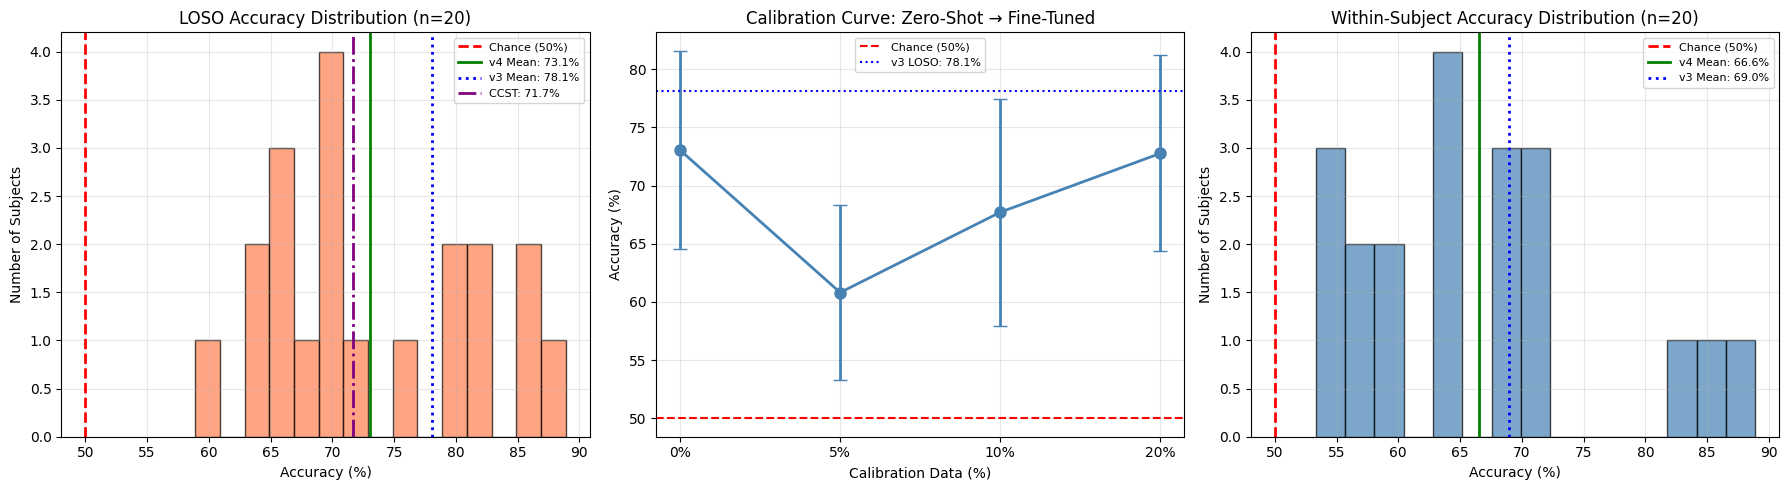

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. LOSO histogram
axes[0].hist(loso_accs * 100, bins=15, color='coral', alpha=0.7, edgecolor='black')
axes[0].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[0].axvline(x=loso_accs.mean()*100, color='green', ls='-', lw=2,
                label=f'v4 Mean: {loso_accs.mean()*100:.1f}%')
axes[0].axvline(x=78.1, color='blue', ls=':', lw=2, label='v3 Mean: 78.1%')
axes[0].axvline(x=71.70, color='purple', ls='-.', lw=2, label='CCST: 71.7%')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_ylabel('Number of Subjects')
axes[0].set_title(f'LOSO Accuracy Distribution (n={N_SUBJECTS_USED})')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Calibration curve
cal_fracs = ['0%'] + [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]
cal_means = [loso_accs.mean() * 100]
cal_stds = [loso_accs.std() * 100]
for frac_key in [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]:
    if frac_key in ft_results and ft_results[frac_key]:
        accs = np.array([r['ft_accuracy'] for r in ft_results[frac_key]])
        cal_means.append(accs.mean() * 100)
        cal_stds.append(accs.std() * 100)
    else:
        cal_means.append(np.nan)
        cal_stds.append(np.nan)

axes[1].errorbar(range(len(cal_fracs)), cal_means, yerr=cal_stds,
                 marker='o', markersize=8, capsize=5, color='steelblue', lw=2)
axes[1].set_xticks(range(len(cal_fracs)))
axes[1].set_xticklabels(cal_fracs)
axes[1].axhline(y=50, color='red', ls='--', lw=1.5, label='Chance (50%)')
axes[1].axhline(y=78.1, color='blue', ls=':', lw=1.5, label='v3 LOSO: 78.1%')
axes[1].set_xlabel('Calibration Data (%)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Calibration Curve: Zero-Shot → Fine-Tuned')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# 3. Within-subject histogram
axes[2].hist(within_accs_v4 * 100, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
axes[2].axvline(x=50, color='red', ls='--', lw=2, label='Chance (50%)')
axes[2].axvline(x=within_accs_v4.mean()*100, color='green', ls='-', lw=2,
                label=f'v4 Mean: {within_accs_v4.mean()*100:.1f}%')
axes[2].axvline(x=69.0, color='blue', ls=':', lw=2, label='v3 Mean: 69.0%')
axes[2].set_xlabel('Accuracy (%)')
axes[2].set_ylabel('Number of Subjects')
axes[2].set_title(f'Within-Subject Accuracy Distribution (n={N_SUBJECTS_USED})')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'eegtcnet_v4_physionet_results.png'), dpi=150, bbox_inches='tight')
plt.show()

## 15. Comparison Table

In [ ]:
print('VERSION COMPARISON')
print(f'{"":<25s} {"v2":<15s} {"v3":<15s} {"v4":<15s}')
print(f'{"-"*25} {"-"*15} {"-"*15} {"-"*15}')
print(f'{"Architecture":<25s} {"EEGNet+TF":<15s} {"Swin+CCST":<15s} {"StdTF+75tok":<15s}')
print(f'{"Channels":<25s} {"16":<15s} {"64":<15s} {"64":<15s}')
print(f'{"Tokens":<25s} {"20":<15s} {"37":<15s} {"75":<15s}')
print(f'{"Attention":<25s} {"Standard":<15s} {"Swin":<15s} {"Standard":<15s}')
print(f'{"Params":<25s} {"72k":<15s} {"210k":<15s} {"210k":<15s}')
print(f'{"-"*25} {"-"*15} {"-"*15} {"-"*15}')
print(f'{"LOSO":<25s} {"N/A":<15s} {"78.1%":<15s} {f"{loso_accs.mean()*100:.1f}%":<15s}')
print(f'{"Within-Subject":<25s} {"65.5%":<15s} {"69.0%":<15s} {f"{within_accs_v4.mean()*100:.1f}%":<15s}')
print(f'{"CCST benchmark":<25s} {"":<15s} {"71.70%":<15s} {"71.70%":<15s}')
print()

# Fine-tuning comparison
print('Fine-Tuning Results (LOSO + calibration):')
print(f'{"Calibration %":<20s} {"Accuracy":<20s} {"vs Zero-Shot":<20s}')
print(f'{"-"*20} {"-"*20} {"-"*20}')
print(f'{"0% (zero-shot)":<20s} {f"{loso_accs.mean()*100:.1f}%":<20s} {"—":<20s}')
for frac_key in [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]:
    if frac_key in ft_results and ft_results[frac_key]:
        accs = np.array([r['ft_accuracy'] for r in ft_results[frac_key]])
        imps = np.array([r['improvement'] for r in ft_results[frac_key]])
        print(f'{frac_key:<20s} {f"{accs.mean()*100:.1f}%":<20s} {f"{imps.mean()*100:+.1f}%":<20s}')
    else:
        print(f'{frac_key:<20s} {"N/A":<20s} {"N/A":<20s}')


VERSION COMPARISON
                          v2              v3              v4             
------------------------- --------------- --------------- ---------------
Architecture              EEGNet+TF       Swin+CCST       StdTF+75tok    
Channels                  16              64              64             
Tokens                    20              37              75             
Attention                 Standard        Swin            Standard       
Params                    72k             210k            210k           
------------------------- --------------- --------------- ---------------
LOSO                      N/A             78.1%           73.1%          
Within-Subject            65.5%           69.0%           66.6%          
CCST benchmark                            71.70%          71.70%         

Fine-Tuning Results (LOSO + calibration):
Calibration %        Accuracy             vs Zero-Shot        
-------------------- -------------------- -------------------

## 16. Save Results & Final Summary

In [ ]:
# Save LOSO results
loso_results_dict = {r['subject']: {'accuracy': float(r['accuracy'])} for r in loso_results}
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v4_loso_results.npy'), loso_results_dict)
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v4_loso_accs.npy'), loso_accs)

# Save fine-tuning results
ft_save = {}
for frac_key, results in ft_results.items():
    ft_save[frac_key] = {
        r['subject']: {
            'ft_accuracy': float(r['ft_accuracy']),
            'zero_shot': float(r['zero_shot']),
            'improvement': float(r['improvement']),
            'n_calib': int(r['n_calib'])
        } for r in results
    }
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v4_finetune_results.npy'), ft_save)

# Save within-subject results
within_results_dict = {r['subject']: {
    'accuracy_mean': float(r['accuracy']),
    'accuracy_std': float(r['std']),
    'fold_accs': [float(a) for a in r['fold_accs']],
    'n_trials': int(r['n_trials'])
} for r in within_results_v4}
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v4_within_results.npy'), within_results_dict)
np.save(os.path.join(SAVE_DIR, 'eegtcnet_v4_within_accs.npy'), within_accs_v4)

print('FINAL RESULTS: EEGTCNet v4 on PhysioNet')
print(f'Model: EEGTCNet v4 ({total_params:,} params, Standard Transformer, {model.seq_len} tokens)')
print(f'Dataset: PhysioNet ({len(preprocessed_data)} subjects, {N_CHANNELS}ch, {SFREQ}Hz)')
print(f'Runs: {MI_ME_RUNS} (execution + imagery)')
print(f'')
print(f'LOSO Cross-Subject Accuracy: {loso_accs.mean()*100:.1f}% +/- {loso_accs.std()*100:.1f}%')
print(f'  v3 comparison: 78.1%')
print(f'  CCST benchmark: 71.70%')
print(f'  Min: {loso_accs.min()*100:.1f}%, Max: {loso_accs.max()*100:.1f}%')
print(f'  Above chance (>50%): {np.sum(loso_accs > 0.5)}/{len(loso_results)}')
print(f'')
for frac_key in [f'{int(f*100)}%' for f in CALIBRATION_FRACTIONS]:
    if frac_key in ft_results and ft_results[frac_key]:
        accs = np.array([r['ft_accuracy'] for r in ft_results[frac_key]])
        imps = np.array([r['improvement'] for r in ft_results[frac_key]])
        print(f'LOSO + Fine-Tune ({frac_key}): {accs.mean()*100:.1f}% +/- {accs.std()*100:.1f}% (delta={imps.mean()*100:+.1f}%)')
print(f'')
print(f'Within-Subject Accuracy (5-Fold CV): {within_accs_v4.mean()*100:.1f}% +/- {within_accs_v4.std()*100:.1f}%')
print(f'  v3 comparison: 69.0%')
print(f'  Min: {within_accs_v4.min()*100:.1f}%, Max: {within_accs_v4.max()*100:.1f}%')
print(f'')
print(f'All results saved to: {SAVE_DIR}')


FINAL RESULTS: EEGTCNet v4 on PhysioNet
Model: EEGTCNet v4 (213,298 params, Standard Transformer, 75 tokens)
Dataset: PhysioNet (20 subjects, 64ch, 160Hz)
Runs: [3, 4, 7, 8, 11, 12] (execution + imagery)

LOSO Cross-Subject Accuracy: 73.1% +/- 8.5%
  v3 comparison: 78.1%
  CCST benchmark: 71.70%
  Min: 58.9%, Max: 88.9%
  Above chance (>50%): 20/20

LOSO + Fine-Tune (5%): 60.8% +/- 7.5% (delta=-12.2%)
LOSO + Fine-Tune (10%): 67.7% +/- 9.8% (delta=-5.3%)
LOSO + Fine-Tune (20%): 72.8% +/- 8.4% (delta=-0.3%)

Within-Subject Accuracy (5-Fold CV): 66.6% +/- 9.7%
  v3 comparison: 69.0%
  Min: 53.3%, Max: 88.9%

All results saved to: /content/drive/My Drive/saved_models_v4
